<a href="https://colab.research.google.com/github/SHRUTI3045/Shruti_ML_Algorithms/blob/main/kmeans_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [8]:
df = pd.read_csv('/content/sales-of-shampoo-over-a-three-ye.csv')

df.head()


,Month,Sales of shampoo over a three year period
0,1-Jan,266.0
1,1-Feb,145.9
2,1-Mar,183.1
3,1-Apr,119.3
4,1-May,180.3


In [5]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

for col in df.columns:
    print(col, ":", df[col].nunique())

Missing values:
 Month                                        0
Sales of shampoo over a three year period    0
dtype: int64
Duplicates: 0
Month : 36
Sales of shampoo over a three year period : 36


In [9]:
df[['Month_num', 'Month_name']] = df['Month'].str.split('-', expand=True)

df['Month_num'] = df['Month_num'].astype(int)

df['Month_name'] = pd.to_datetime(df['Month_name'], format='%b').dt.month

In [11]:
# Filter (example since no revenue column)
df_filtered = df[df['Sales of shampoo over a three year period'] > 100]

# Top 10 (dummy since no customer column)
top_values = df.sort_values(by='Sales of shampoo over a three year period', ascending=False).head(10)

# Summary
total_revenue = df['Sales of shampoo over a three year period'].sum()
avg_order = df['Sales of shampoo over a three year period'].mean()

print(total_revenue, avg_order)

11253.599999999999 312.59999999999997


In [12]:
# Fill missing
df.fillna(df.mean(numeric_only=True), inplace=True)

# Outlier detection (IQR)
Q1 = df['Sales of shampoo over a three year period'].quantile(0.25)
Q3 = df['Sales of shampoo over a three year period'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Sales of shampoo over a three year period'] >= Q1 - 1.5*IQR) & (df['Sales of shampoo over a three year period'] <= Q3 + 1.5*IQR)]

# Remove duplicates
df.drop_duplicates(inplace=True)

In [13]:
# Profit (dummy assumption)
df['Cost'] = df['Sales of shampoo over a three year period'] * 0.7
df['Profit'] = df['Sales of shampoo over a three year period'] - df['Cost']

# Binning
df['Sales_Category'] = pd.cut(df['Sales of shampoo over a three year period'], bins=3, labels=['Low', 'Medium', 'High'])

# Scaling
scaler = MinMaxScaler()
df[['Sales_scaled']] = scaler.fit_transform(df[['Sales of shampoo over a three year period']])

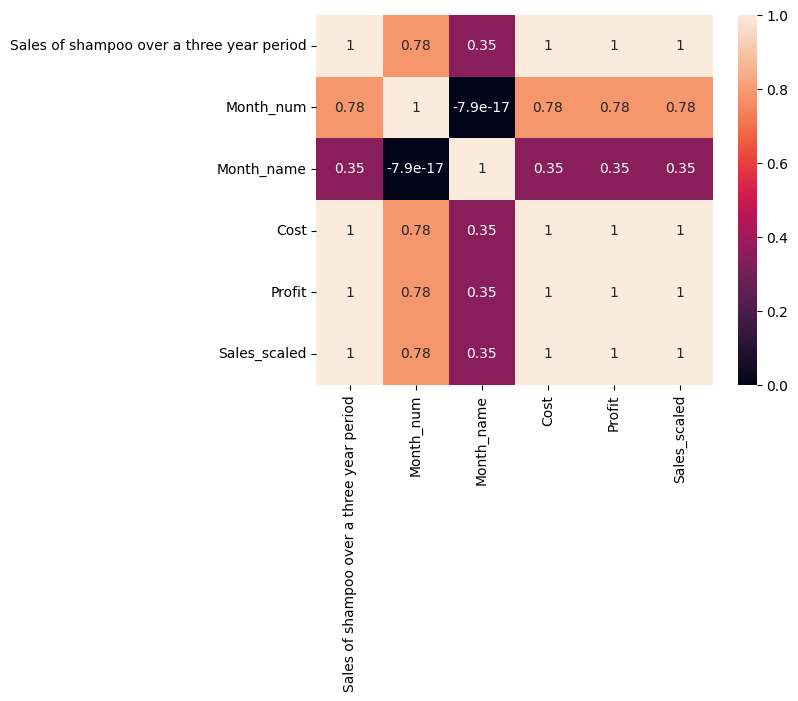

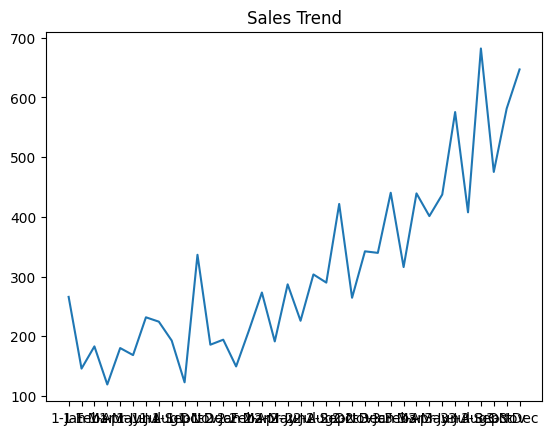

0.8945388528534595


In [14]:
# Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Trend
plt.plot(df['Month'], df['Sales of shampoo over a three year period'])
plt.title("Sales Trend")
plt.show()

# Skewness
print(df['Sales of shampoo over a three year period'].skew())

In [16]:
# Probability
prob = len(df[df['Sales of shampoo over a three year period'] > 500]) / len(df)

# Mean, variance
print(df['Sales of shampoo over a three year period'].mean(), df['Sales of shampoo over a three year period'].var())

# Z-score
from scipy.stats import zscore
df['Z_score'] = zscore(df['Sales of shampoo over a three year period'])

df_anomalies = df[np.abs(df['Z_score']) > 3]

312.59999999999997 22182.27885714285


In [17]:
X = df[['Sales_scaled']]
y = df['Sales_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

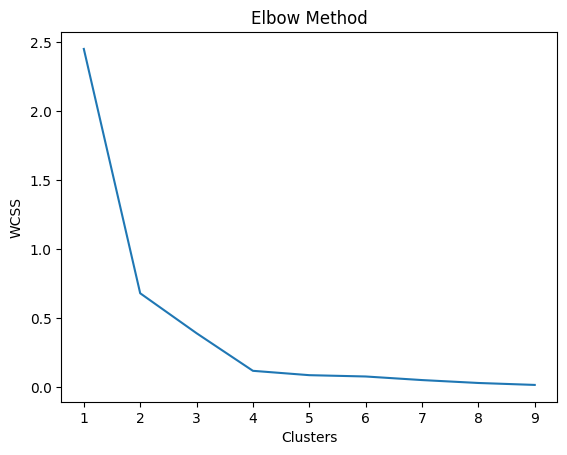

In [18]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

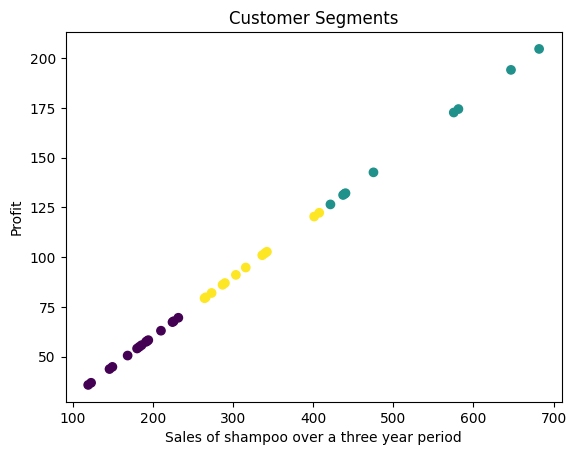

In [20]:
plt.scatter(df['Sales of shampoo over a three year period'], df['Profit'], c=df['Cluster'])
plt.xlabel("Sales of shampoo over a three year period")
plt.ylabel("Profit")
plt.title("Customer Segments")
plt.show()

In [23]:
numeric_cols = df.select_dtypes(include=np.number)

df.groupby('Cluster')[numeric_cols.columns].mean()

,Sales of shampoo over a three year period,Month_num,Month_name,Cost,Profit,Sales_scaled,Z_score,Cluster
Cluster,,,,,,,,
0,181.753333,1.333333,5.600000,127.227333,54.526000,0.110989,-0.890998,0.0
1,522.188889,2.888889,7.888889,365.532222,156.656667,0.715992,1.427192,1.0
2,318.966667,2.166667,6.583333,223.276667,95.690000,0.354837,0.043354,2.0


In [26]:
X = df[['Sales of shampoo over a three year period', 'Profit']]

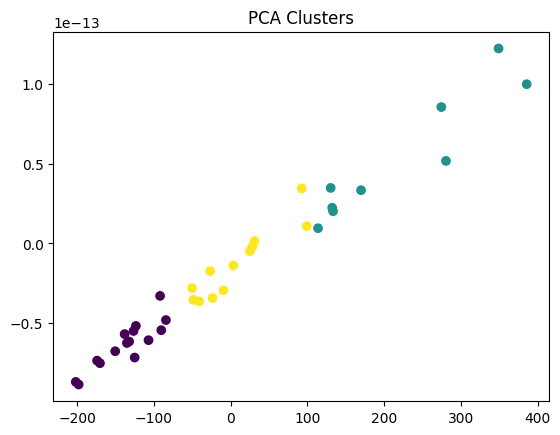

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("PCA Clusters")
plt.show()